# E1 — ISIC 2017 UNet2D Architecture Sweep Summary (all Learning Rates)

**Question.** Across a full 3×3 grid of encoder × merge architectures swept over four learning rates, which (architecture, LR) pair produces the best ISIC 2017 segmentation model — and is the best-performing LR the same for every architecture?

**Design.** 36 single-seed runs: a 3×3 grid of **encoder** (`classical`, `se`, `he2`) × **merge** (`he2`, `attention_gate`, `classical`), each trained at four fixed learning rates (`1e-4`, `3e-4`, `6e-4`, `1e-3`) — 9 architectures × 4 LRs. The performance metric is the Dice coefficient at threshold 0.5 on the ISIC 2017 validation set. This is a joint architecture × LR sweep: every architecture is evaluated at all four LRs, so the analysis selects both the architecture **and** its accompanying LR. This notebook aggregates across the four per-LR experiments to compare architectures within and across LRs and to read off the best LR for each.

**Source.** Four MLflow databases under `mlruns/`, one per LR — `E1-isic2017-unet2d-model-lr-1seed.db` (`3e-4`), `…-modelsw-lr_6e-4-1seed.db`, `…-lr_1e-3-1seed.db`, `…-lr_1e-4-1seed.db` — 36 runs (9 architectures × 4 LRs), all `FINISHED`. Each per-LR notebook (`E1_isic2017_unet2d_modelsw_lr_*_1seed_analysis.ipynb`) holds the full run-level breakdown.

## Executive summary

- Screen: 3×3 encoder × merge grid for 4 LRs ({`1e-4`, `3e-4`, `6e-4`, `1e-3`}), 36 single-seed runs; metric = val Dice @ 0.5
- Selection criterion: highest tail-mean (last-10-epoch) Dice, tie-broken on cross-LR std, overfitting gap and throughput (§2)

| Criterion (at `lr=3e-4`) | `classical+he2` | `classical+attention_gate` |
|---|---|---|
| Peak Dice | **0.8427** | 0.8412 |
| Tail-mean Dice | 0.8259 | **0.8265** |
| Mean tail-Dice across 4 LRs | 0.8205 | **0.8211** |
| Std across 4 LRs | **0.0039** | 0.0056 |
| Overfitting gap | **0.078** | 0.084 |
| Throughput (sps) | **140** | 123 |

**Findings:**
- `lr=3e-4` is the best LR for the recommended `classical` architectures and the modal winner overall (best plateau LR for 6 of 9 architectures); 3 architectures peak elsewhere (`1e-3` or `6e-4`), so the optimal LR is not uniform across the grid
- `classical` is the top encoder at every LR (+`0.010–0.016` over `se`);
- `he2` and `attention_gate` merges tie within single-seed noise (Δ `0.0006`); `classical` merge lags and is eliminated
- `he2` wins every cost/reliability axis: 14 % faster, lower overfitting, lower cross-LR std

**Decision: `classical` encoder + `he2` merge at `lr=3e-4`.** The `he2`/`attention_gate` tie-break is resolved at multi-seed in E2.

## 1. Data

Load and concatenate the four per-LR MLflow databases into a single sweep table (`all_runs`), one row per run, tagged with its learning rate. `summarize_runs` reduces each run to peak / tail-plateau / final metrics; `load_sweep_runs` stacks the four experiments and adds the `lr` column the cross-LR helpers pivot on.

In [10]:
# ── Imports ──────────────────────────────────────────────────────────────────
import sys
from pathlib import Path

PROJECT_ROOT = Path('/teamspace/studios/this_studio/repos/SkiNet')
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd

from SkiNet.Utils.analysis.lr_sweep import (
    load_sweep_runs,
    best_run_per_group,
    rank_all_runs,
    pivot_dim_effect,
    arch_consistency,
)
from SkiNet.Utils.analysis.plotting import plot_group_bar, plot_sweep_facet

# ── Configuration — every tunable argument lives in this cell ────────────────
MLRUNS  = PROJECT_ROOT / 'mlruns'  # directory holding the per-LR MLflow databases
MONITOR = 'val_dice'               # validation metric summarised per run

# group label (learning rate) → (db_filename, mlflow_experiment_name)
EXPERIMENTS = {
    '3e-4': ('E1-isic2017-unet2d-model-lr-1seed.db',        'E1-isic2017-unet2d-model-lr-1seed'),
    '6e-4': ('E1-isic2017-unet2d-modelsw-lr_6e-4-1seed.db', 'E1-isic2017-unet2d-modelsw-lr_6e-4-1seed'),
    '1e-3': ('E1-isic2017-unet2d-modelsw-lr_1e-3-1seed.db', 'E1-isic2017-unet2d-modelsw-lr_1e-3-1seed'),
    '1e-4': ('E1-isic2017-unet2d-modelsw-lr_1e-4-1seed.db', 'E1-isic2017-unet2d-modelsw-lr_1e-4-1seed'),
}
LR_ORDER = ['1e-4', '3e-4', '6e-4', '1e-3']  # canonical LR ordering for tables and facets

# ── Presentation ─────────────────────────────────────────────────────────────
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.4f}'.format)

In [11]:
# ── Load: 36 runs = 9 architectures × 4 learning rates ───────────────────────
all_runs = load_sweep_runs(EXPERIMENTS, MLRUNS, group_by='lr', monitor=MONITOR)
f"Loaded {len(all_runs)} runs across {all_runs['lr'].nunique()} LRs: {sorted(all_runs['lr'].unique())}"

"Loaded 36 runs across 4 LRs: ['1e-3', '1e-4', '3e-4', '6e-4']"

## 2. Selection methodology

### 2.1 Primary ranking metric

At one seed, runs are ranked on **`val_dice_tail_mean`** — the mean validation Dice (threshold 0.5) over the **last 10 epochs**, i.e. the stable plateau — rather than the single best epoch (`val_dice_max`). Peak Dice is retained as a secondary, reported column.

### 2.2 Selection rules

The architecture is selected in two passes over the 9 encoder × merge combinations:

| # | Criterion | Operational definition |
|---|---|---|
| 1 | **Best plateau Dice** | Highest `val_dice_tail_mean` at the best LR, evaluated per encoder and per merge family (§3.4–3.5) and per full architecture (§3.6) |
| 2 | **Cross-LR robustness** | Lowest std of `val_dice_tail_mean` across the 4 LRs — prefers architectures that do not depend on LR tuning (§3.6) |

When two architectures are tied on plateau Dice **within single-seed noise** (Δ ≲ `0.001`), the decision falls to the secondary cost/reliability axes:

| Tie-break axis | Column | Preference |
|---|---|---|
| Generalisation | `generalization_gap_final` (`train_dice − val_dice`) | lower |
| Stability from peak | `drop_peak_to_final` (`val_dice_max − final_val_dice`) | lower |
| Throughput | `samples_per_sec` | higher |

### 2.3 Why a single seed is sufficient here

E1 is a combined architecture-learning rate **screen**: its job is to eliminate clearly inferior combinations and surface the one or two finalists. Resolving a remaining tie-break requires the paired multi-seed design, which is carried out in **E2**.

## 3. Results

### 3.1 Best run per LR

Top-ranked run at each learning rate (by `val_dice_tail_mean`) with key secondary metrics — the per-LR champions feeding the cross-LR comparison.

In [12]:
best_run_per_group(all_runs)

,lr,encoder,merge,val_dice_tail_mean,val_dice_max,val_dice_max_epoch,generalization_gap_final,samples_per_sec
0,3e-4,classical,attention_gate,0.8265,0.8412,74,0.084,123.2
1,6e-4,classical,attention_gate,0.8252,0.8375,99,0.098,114.2
2,1e-3,classical,classical,0.8213,0.8306,92,0.081,158.9
3,1e-4,classical,he2,0.8188,0.8273,97,0.091,128.0


### 3.2 All 36 runs ranked

Full cross-LR ranking sorted by `val_dice_tail_mean` (stable-plateau Dice). Columns:

| column | what it measures |
|---|---|
| `val_dice_max` | Single best-epoch Dice at fixed threshold 0.5 — the peak this run reached |
| `val_dice_tail_mean` | Mean Dice over last 10 epochs — the stable plateau |
| `val_dice_tail_std` | Std over the same tail window — convergence noise |
| `val_dice_max_epoch` | Epoch at which the peak occurred |
| `gen_gap` | `train_dice − val_dice` at the final epoch — overfitting signal |
| `drop` | `val_dice_max − final_val_dice` — how much the run fell from peak to last epoch |

In [13]:
rank_all_runs(all_runs)

,lr,encoder,merge,val_dice_max,val_dice_tail_mean,tail_std,epoch,gen_gap,drop,samples_per_sec
0,3e-4,classical,attention_gate,0.8412,0.8265,0.0107,74,0.084,0.019,123.2
1,3e-4,classical,he2,0.8427,0.8259,0.0109,97,0.078,0.017,140.3
2,6e-4,classical,attention_gate,0.8375,0.8252,0.0114,99,0.098,0.032,114.2
3,1e-3,classical,classical,0.8306,0.8213,0.0085,92,0.081,0.012,158.9
4,6e-4,classical,he2,0.8334,0.8206,0.0078,97,0.082,0.011,131.9
5,1e-4,classical,he2,0.8273,0.8188,0.0058,97,0.091,0.018,128.0
6,1e-3,classical,attention_gate,0.8277,0.8178,0.0068,88,0.082,0.008,116.6
7,1e-3,classical,he2,0.8320,0.8168,0.0092,92,0.077,0.009,138.3
8,3e-4,classical,classical,0.8299,0.8165,0.0107,84,0.090,0.014,157.3
9,6e-4,classical,classical,0.8319,0.8153,0.0106,99,0.094,0.021,157.1


### 3.3 LR comparison — tail-mean Dice per architecture

Bar chart of tail-mean (plateau) Dice per architecture, grouped by LR, to visualise the LR effect on each combination.

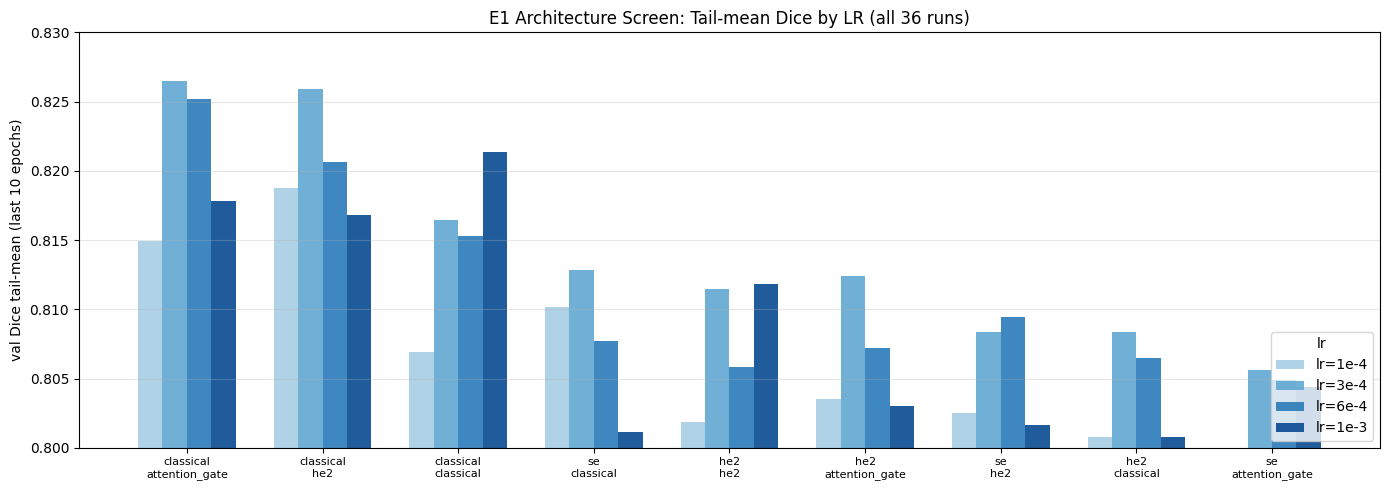

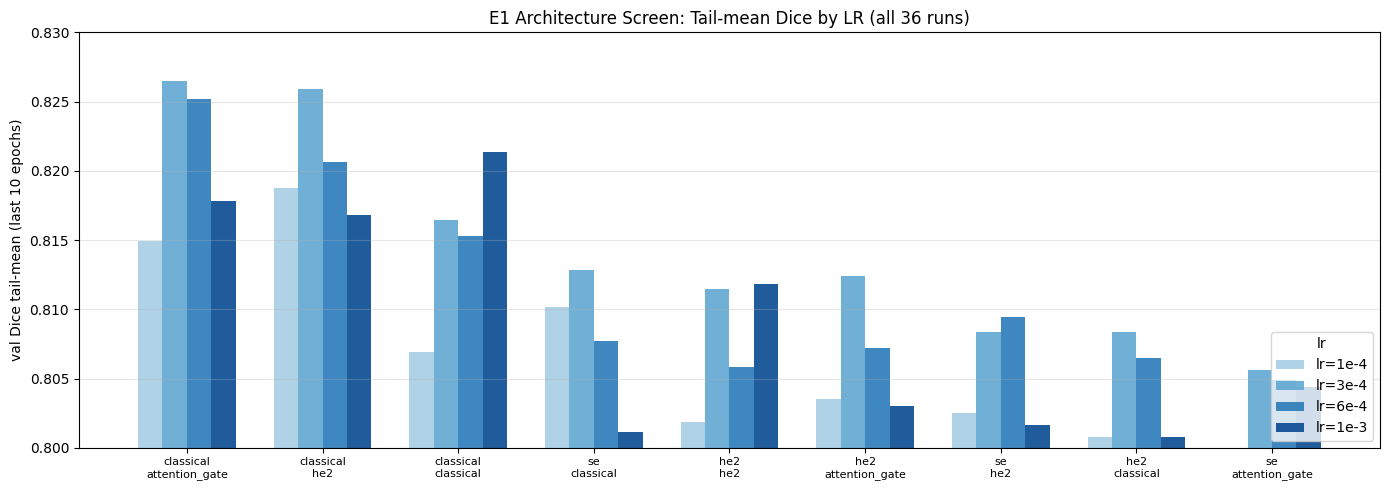

In [14]:
plot_group_bar(
    all_runs,
    group_col='lr',
    group_order=LR_ORDER,
    value_col='val_dice_tail_mean',
    title='E1 Architecture Screen: Tail-mean Dice by LR (all 36 runs)',
    ylabel='val Dice tail-mean (last 10 epochs)',
    ylim=(0.800, 0.830),
)

### 3.4 Encoder family effect by LR

Mean tail-mean (plateau) Dice per encoder family at each LR (averaged over the 3 merge modes).

In [15]:
pivot_dim_effect(
    all_runs, 'encoder',
    group_order=LR_ORDER,
    dim_order=['classical', 'se', 'he2'],
)

### 3.5 Merge family effect by LR

Mean tail-mean (plateau) Dice per merge family at each LR (averaged over the 3 encoder modes).

In [16]:
pivot_dim_effect(
    all_runs, 'merge',
    group_order=LR_ORDER,
    dim_order=['he2', 'attention_gate', 'classical'],
)

### 3.6 Architecture consistency across LRs

Aggregated across all 4 LRs, each architecture's mean / std / min / max tail-mean Dice (the metric `arch_consistency` ranks on). Low std means the architecture is robust to LR choice; high std means it benefits from LR tuning.

**Key finding:** the two `classical`-encoder architectures lead and are separated by noise. `classical+attention_gate` has the highest mean (`0.8211`) but the larger cross-LR spread (std `0.0056`); `classical+he2` trails by `0.0006` on the mean (`0.8205`) while being the more stable of the two (std `0.0039`). `attention_gate`'s edge is driven mainly by its result at `lr=3e-4`.

In [17]:
arch_consistency(all_runs)

,encoder,merge,mean_tail_mean,std_tail_mean,min_tail_mean,max_tail_mean
0,classical,attention_gate,0.8211,0.0056,0.8149,0.8265
1,classical,he2,0.8205,0.0039,0.8168,0.8259
2,classical,classical,0.8150,0.0060,0.8069,0.8213
3,se,classical,0.8080,0.0050,0.8011,0.8128
4,he2,he2,0.8078,0.0048,0.8018,0.8119
5,he2,attention_gate,0.8065,0.0043,0.8030,0.8124
6,se,he2,0.8055,0.0040,0.8016,0.8095
7,he2,classical,0.8041,0.0039,0.8008,0.8083
8,se,attention_gate,0.8033,0.0034,0.7982,0.8056


### 3.7 Throughput vs accuracy frontier

Four panels share the same y-axis — this makes the LR effect directly readable as vertical shifts between panels.

**Encoding:** colour = merge mode, marker shape = encoder family. Error bars show ±`val_dice_tail_std` (convergence noise over the last 10 epochs). The ring marks `classical+he2` — the recommended architecture.

**How to read this:**
- Top-right corner of any panel = best accuracy *and* fastest training.
- The `lr=3e-4` panel sits highest overall - it is the best LR for the leading (`classical`) architectures
- Within that panel, `classical+he2` sits furthest right among the high-Dice points - it is the fastest architecture that does not sacrifice Dice.
- `classical+attention_gate` is the only competitor: slightly higher Dice in this panel, but visibly slower (further left) and with a wider error bar — less stable convergence.

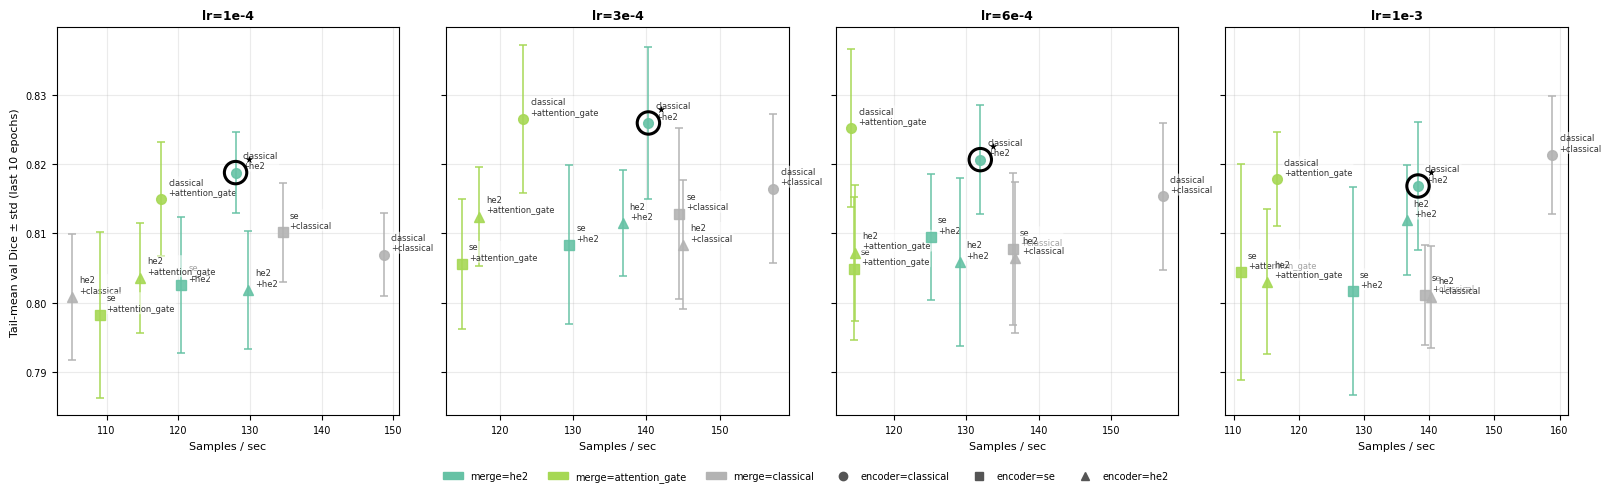

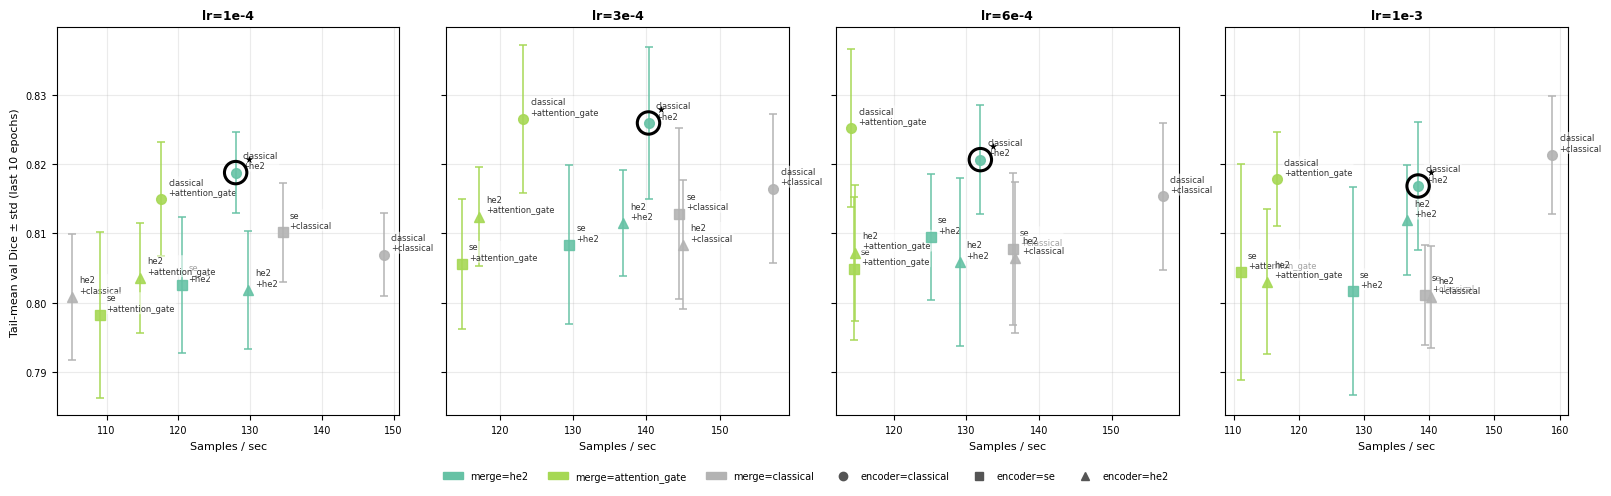

In [18]:
plot_sweep_facet(
    all_runs,
    facet_col='lr',
    facet_order=LR_ORDER,
    y_col='val_dice_tail_mean',
    yerr_col='val_dice_tail_std',
    color_col='merge',
    marker_col='encoder',
    color_order=['he2', 'attention_gate', 'classical'],
    marker_order=['classical', 'se', 'he2'],
    highlight={'encoder': 'classical', 'merge': 'he2', 'label': '★'},
    xlabel='Samples / sec',
    ylabel='Tail-mean val Dice ± std (last 10 epochs)',
)

## 4. Conclusion

### Recommendation: `classical` encoder + `he2` merge at `lr=3e-4`

| criterion | `classical+he2` | `classical+attention_gate` | winner |
|---|---|---|---|
| Mean tail-Dice across 4 LRs | 0.8205 | **0.8211** | att_gate (+0.0006) |
| Std tail-Dice across 4 LRs | **0.0039** | 0.0056 | **he2** |
| Best single-run Dice at lr=3e-4 | **0.8427** | 0.8412 | **he2** (+0.0015) |
| Tail-mean at lr=3e-4 | 0.8259 | **0.8265** | att_gate (+0.0006) |
| Overfitting gap at lr=3e-4 | **0.078** | 0.084 | **he2** |
| Throughput at lr=3e-4 | **140 sps** | 123 sps | **he2** (+14 %) |

`classical+attention_gate` has a marginal edge on mean and tail-mean Dice (`+0.0006`) — a difference well within single-seed noise. Against that, `classical+he2` wins on every cost and reliability axis: lower cross-LR std (more robust to LR choice), higher peak Dice, lower overfitting, and 14 % faster training. At multi-seed the `+0.0006` Dice gap is expected to vanish; the throughput and stability advantages are structural. The multi-seed tie-break is carried out in E2.